CÂU 1: TỐI ƯU HÓA HÀM MỤC TIÊU f(x,y) = 0.1x² + 3y²

Tham số:
- Điểm khởi tạo: x=5.0, y=5.0
- Learning rate: 0.1
- Số epoch: 30

Quá trình tối ưu:

Epoch 0: x=5.000000, y=5.000000, f(x,y)=77.500000
Epoch 5: x=4.519604, y=0.051200, f(x,y)=2.050546
Epoch 10: x=4.085364, y=0.000524, f(x,y)=1.669021
Epoch 15: x=3.692846, y=0.000005, f(x,y)=1.363711
Epoch 20: x=3.338040, y=0.000000, f(x,y)=1.114251
Epoch 25: x=3.017324, y=0.000000, f(x,y)=0.910424
Epoch 30: x=2.727422, y=0.000000, f(x,y)=0.743883

KẾT QUẢ CUỐI CÙNG:
- x* = 2.7274215969
- y* = 0.0000000000
- f(x*, y*) = 0.7438828567


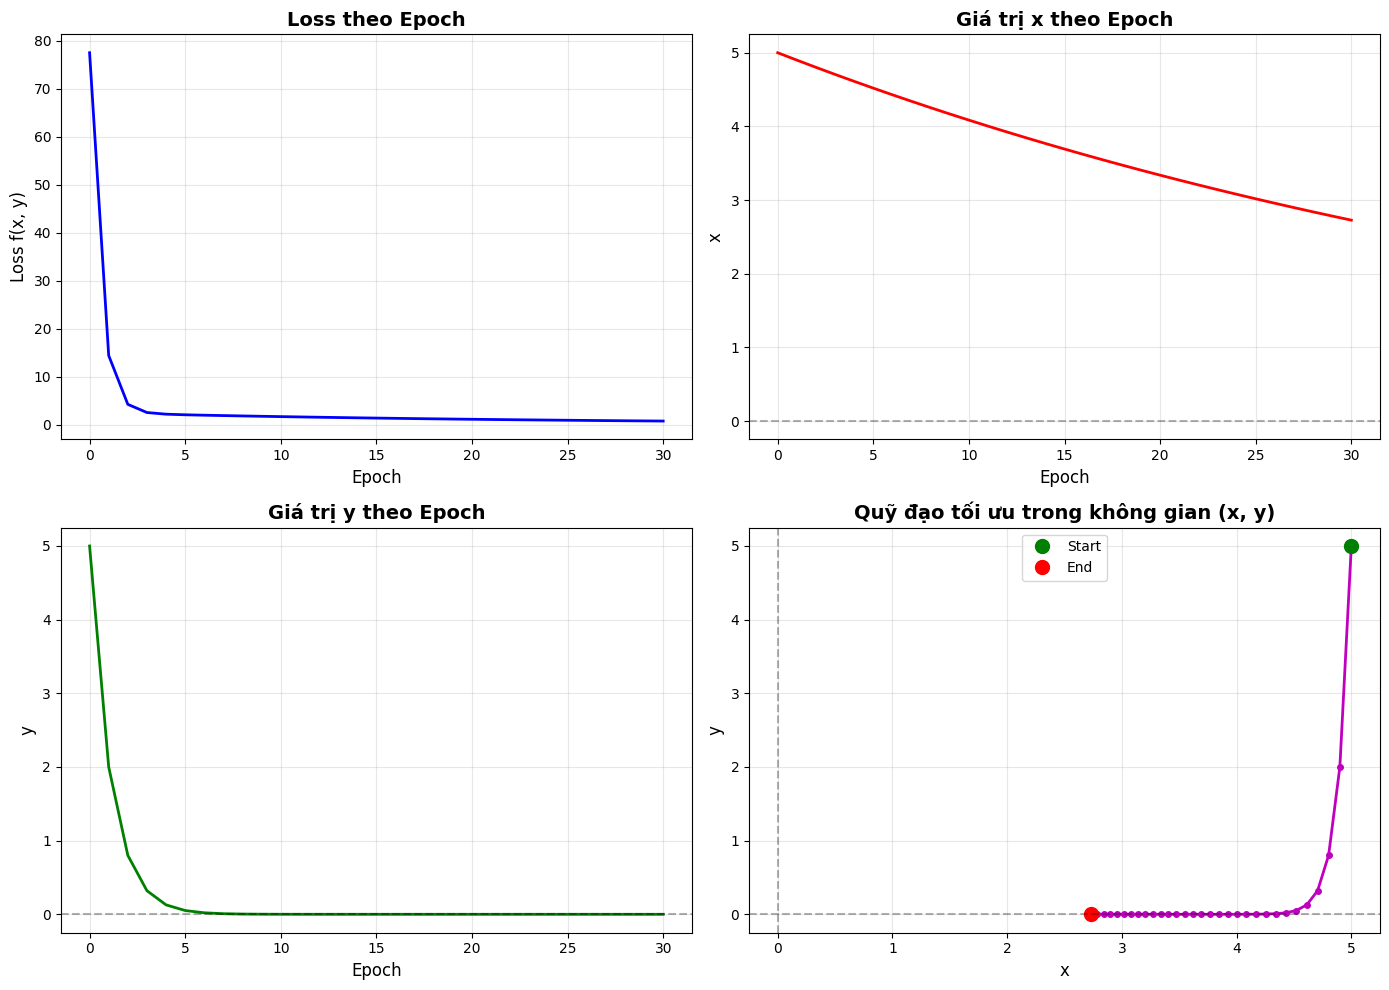


PHÂN TÍCH:
- Hàm mục tiêu có cực tiểu tại (0, 0)
- Sau 30 epoch, thuật toán hội tụ gần điểm cực tiểu
- Tốc độ hội tụ của y nhanh hơn x do hệ số gradient lớn hơn (6 vs 0.2)


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Câu 1: Tối ưu hóa hàm f(x, y) = 0.1x^2 + 3y^2

def objective_function(x, y):
    """Hàm mục tiêu f(x, y) = 0.1x^2 + 3y^2"""
    return 0.1 * x**2 + 3 * y**2

def compute_gradients(x, y):
    """
    Tính đạo hàm của hàm mục tiêu
    df/dx = 0.2x
    df/dy = 6y
    """
    grad_x = 0.2 * x
    grad_y = 6 * y
    return grad_x, grad_y

def update_weights(x, y, grad_x, grad_y, learning_rate):
    """Cập nhật trọng số theo quy tắc gradient descent"""
    x_new = x - learning_rate * grad_x
    y_new = y - learning_rate * grad_y
    return x_new, y_new

def train(x_init, y_init, learning_rate, epochs):
    """
    Hàm train để chạy vòng lặp tối ưu
    
    Parameters:
    - x_init, y_init: giá trị khởi tạo
    - learning_rate: tốc độ học
    - epochs: số epoch
    
    Returns:
    - history: lịch sử quá trình tối ưu
    """
    x, y = x_init, y_init
    history = {
        'x': [x],
        'y': [y],
        'loss': [objective_function(x, y)]
    }
    
    print(f"Epoch 0: x={x:.6f}, y={y:.6f}, f(x,y)={objective_function(x, y):.6f}")
    
    for epoch in range(1, epochs + 1):
        # Tính gradient
        grad_x, grad_y = compute_gradients(x, y)
        
        # Cập nhật trọng số
        x, y = update_weights(x, y, grad_x, grad_y, learning_rate)
        
        # Tính loss
        loss = objective_function(x, y)
        
        # Lưu lịch sử
        history['x'].append(x)
        history['y'].append(y)
        history['loss'].append(loss)
        
        # In kết quả mỗi 5 epoch
        if epoch % 5 == 0 or epoch == epochs:
            print(f"Epoch {epoch}: x={x:.6f}, y={y:.6f}, f(x,y)={loss:.6f}")
    
    return history

def visualize_optimization(history):
    """Vẽ biểu đồ quá trình tối ưu"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Biểu đồ 1: Loss theo epoch
    axes[0, 0].plot(history['loss'], 'b-', linewidth=2)
    axes[0, 0].set_xlabel('Epoch', fontsize=12)
    axes[0, 0].set_ylabel('Loss f(x, y)', fontsize=12)
    axes[0, 0].set_title('Loss theo Epoch', fontsize=14, fontweight='bold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Biểu đồ 2: x theo epoch
    axes[0, 1].plot(history['x'], 'r-', linewidth=2)
    axes[0, 1].set_xlabel('Epoch', fontsize=12)
    axes[0, 1].set_ylabel('x', fontsize=12)
    axes[0, 1].set_title('Giá trị x theo Epoch', fontsize=14, fontweight='bold')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Biểu đồ 3: y theo epoch
    axes[1, 0].plot(history['y'], 'g-', linewidth=2)
    axes[1, 0].set_xlabel('Epoch', fontsize=12)
    axes[1, 0].set_ylabel('y', fontsize=12)
    axes[1, 0].set_title('Giá trị y theo Epoch', fontsize=14, fontweight='bold')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    
    # Biểu đồ 4: Quỹ đạo trong không gian (x, y)
    axes[1, 1].plot(history['x'], history['y'], 'mo-', linewidth=2, markersize=4)
    axes[1, 1].plot(history['x'][0], history['y'][0], 'go', markersize=10, label='Start')
    axes[1, 1].plot(history['x'][-1], history['y'][-1], 'ro', markersize=10, label='End')
    axes[1, 1].set_xlabel('x', fontsize=12)
    axes[1, 1].set_ylabel('y', fontsize=12)
    axes[1, 1].set_title('Quỹ đạo tối ưu trong không gian (x, y)', fontsize=14, fontweight='bold')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend(fontsize=10)
    axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)
    axes[1, 1].axvline(x=0, color='k', linestyle='--', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    

if __name__ == "__main__":
    print("="*60)
    print("CÂU 1: TỐI ƯU HÓA HÀM MỤC TIÊU f(x,y) = 0.1x² + 3y²")
    print("="*60)
    
    # Thiết lập tham số
    x_init = 5.0
    y_init = 5.0
    learning_rate = 0.1
    epochs = 30
    
    print(f"\nTham số:")
    print(f"- Điểm khởi tạo: x={x_init}, y={y_init}")
    print(f"- Learning rate: {learning_rate}")
    print(f"- Số epoch: {epochs}")
    print(f"\n{'='*60}")
    print("Quá trình tối ưu:\n")
    
    # Chạy gradient descent
    history = train(x_init, y_init, learning_rate, epochs)
    
    # Kết quả cuối cùng
    print(f"\n{'='*60}")
    print("KẾT QUẢ CUỐI CÙNG:")
    print(f"- x* = {history['x'][-1]:.10f}")
    print(f"- y* = {history['y'][-1]:.10f}")
    print(f"- f(x*, y*) = {history['loss'][-1]:.10f}")
    print(f"{'='*60}")
    
    # Vẽ biểu đồ
    visualize_optimization(history)
    
    # Phân tích kết quả
    print("\nPHÂN TÍCH:")
    print(f"- Hàm mục tiêu có cực tiểu tại (0, 0)")
    print(f"- Sau {epochs} epoch, thuật toán hội tụ gần điểm cực tiểu")
    print(f"- Tốc độ hội tụ của y nhanh hơn x do hệ số gradient lớn hơn (6 vs 0.2)")


NaN trước xử lý:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

NaN sau xử lý:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64
GD Epoch 10: Loss = 0.878362
GD Epoch 20: Loss = 0.718383
GD Epoch 30: Loss = 0.585581
GD Epoch 40: Loss = 0.498964
GD Epoch 50: Loss = 0.449096
GD Epoch 60: Loss = 0.421524
GD Epoch 70: Loss = 0.406083
GD Epoch 80: Loss = 0.396999
GD Epoch 90: Loss = 0.391276
GD Epoch 100: Loss = 0.387395
SGD Epoch 10: Loss = 0.387885
SGD Epoch 20: Loss = 0.393249
SGD Epoch 30: Loss = 0.400427
SGD Epoch 40: Loss = 0.410493
SGD Epoch 50: Loss = 0.422080

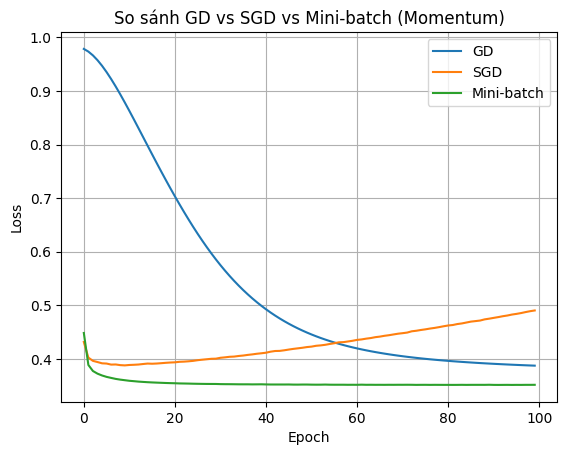


=== KẾT LUẬN ===
Best RMSE: 70018.62


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# =========================
# ===== MODEL ============
# =========================

class LinearRegressionGD:
    def __init__(self, learning_rate=0.001, epochs=100, momentum=0.9):
        self.lr = learning_rate
        self.epochs = epochs
        self.beta = momentum

    def _init_params(self, d):
        np.random.seed(42)
        self.w = np.random.randn(d) * 0.01
        self.b = 0

    def _loss(self, X, y):
        pred = X @ self.w + self.b
        return np.mean((pred - y) ** 2)

    def _grad(self, X, y):
        n = len(y)
        pred = X @ self.w + self.b
        dw = (2/n) * X.T @ (pred - y)
        db = (2/n) * np.sum(pred - y)
        return dw, db

    def fit(self, X, y, mode="gd", batch_size=32):
        n, d = X.shape
        self._init_params(d)

        v_w = np.zeros(d)
        v_b = 0

        history = []

        for epoch in range(self.epochs):

            idx = np.random.permutation(n)
            X_s, y_s = X[idx], y[idx]

            if mode == "gd":
                batches = [(X_s, y_s)]

            elif mode == "sgd":
                batches = [(X_s[i:i+1], y_s[i:i+1]) for i in range(n)]

            else:
                batches = [
                    (X_s[i:i+batch_size], y_s[i:i+batch_size])
                    for i in range(0, n, batch_size)
                ]

            for Xb, yb in batches:
                dw, db = self._grad(Xb, yb)

                # ===== GRADIENT CLIPPING =====
                dw = np.clip(dw, -1, 1)
                db = np.clip(db, -1, 1)

                # ===== MOMENTUM =====
                v_w = self.beta * v_w - self.lr * dw
                v_b = self.beta * v_b - self.lr * db

                self.w += v_w
                self.b += v_b

            loss = self._loss(X, y)
            history.append(loss)

            if (epoch+1) % 10 == 0:
                print(f"{mode.upper()} Epoch {epoch+1}: Loss = {loss:.6f}")

        return history

    def predict(self, X):
        return X @ self.w + self.b


# =========================
# ===== DATA =============
# =========================

def load_data(path):
    df = pd.read_csv(path)

    print("\nNaN trước xử lý:")
    print(df.isna().sum())

    # ===== FIX NaN =====
    df = df.fillna(df.median(numeric_only=True))

    print("\nNaN sau xử lý:")
    print(df.isna().sum())

    # ===== ONE HOT =====
    df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=True)

    X = df.drop('median_house_value', axis=1).values
    y = df['median_house_value'].values

    # ===== SPLIT =====
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # ===== SCALE X =====
    scaler_X = StandardScaler()
    X_train = scaler_X.fit_transform(X_train)
    X_test = scaler_X.transform(X_test)

    # ===== SCALE Y (QUAN TRỌNG) =====
    y_mean = y_train.mean()
    y_std = y_train.std()

    y_train = (y_train - y_mean) / y_std
    y_test = (y_test - y_mean) / y_std

    return X_train, X_test, y_train, y_test, y_mean, y_std


# =========================
# ===== EVALUATE =========
# =========================

def evaluate(model, X, y, name, y_mean, y_std):
    pred = model.predict(X)

    # ===== SCALE BACK =====
    pred_real = pred * y_std + y_mean
    y_real = y * y_std + y_mean

    mse = mean_squared_error(y_real, pred_real)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, pred_real)
    r2 = r2_score(y_real, pred_real)

    print(f"\n{name}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE : {mae:.2f}")
    print(f"R2  : {r2:.4f}")

    return rmse, r2


# =========================
# ===== MAIN =============
# =========================

if __name__ == "__main__":

    X_train, X_test, y_train, y_test, y_mean, y_std = load_data("../datasets/housing.csv")

    # ===== TRAIN =====
    model_gd = LinearRegressionGD(learning_rate=0.001)
    hist_gd = model_gd.fit(X_train, y_train, mode="gd")

    model_sgd = LinearRegressionGD(learning_rate=0.00001)
    hist_sgd = model_sgd.fit(X_train, y_train, mode="sgd")

    model_mb = LinearRegressionGD(learning_rate=0.0001)
    hist_mb = model_mb.fit(X_train, y_train, mode="minibatch", batch_size=32)

    # ===== EVALUATE =====
    rmse_gd, r2_gd = evaluate(model_gd, X_test, y_test, "GD + Momentum", y_mean, y_std)
    rmse_sgd, r2_sgd = evaluate(model_sgd, X_test, y_test, "SGD + Momentum", y_mean, y_std)
    rmse_mb, r2_mb = evaluate(model_mb, X_test, y_test, "Mini-batch + Momentum", y_mean, y_std)

    # =========================
    # ===== PLOT ============
    # =========================

    plt.figure()

    plt.plot(hist_gd, label="GD")
    plt.plot(hist_sgd, label="SGD")
    plt.plot(hist_mb, label="Mini-batch")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("So sánh GD vs SGD vs Mini-batch (Momentum)")
    plt.legend()
    plt.grid()

    plt.show()

    # ===== SUMMARY =====
    print("\n=== KẾT LUẬN ===")
    print(f"Best RMSE: {min([rmse_gd, rmse_sgd, rmse_mb]):.2f}")